# Logistic Regression Model

This notebook implements Logistic Regression for fraud detection.

The model is chosen for its high interpretability and simplicity.  
Class imbalance is handled using class weighting.

Evaluation focuses on:
- Precision
- Recall
- F1-score
- ROC-AUC



In [17]:
#Imports
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_auc_score, roc_curve

In [18]:
#Load data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("data loaded")

data loaded


In [19]:
#Train baseline model - Logistic Regression
model = LogisticRegression(
    class_weight='balanced',
    max_iter=10000,
    random_state=40
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=40)

In [20]:
y_pred = model.predict(X_test)

#Convert report to dict - save as csv
report = classification_report(y_test, y_pred, output_dict=True)

#Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

#Save to CSV
df_report.to_csv("../results/classification_report_logistic.csv")

#Model evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.58      0.73      2899
           1       0.12      0.94      0.22       185

    accuracy                           0.60      3084
   macro avg       0.56      0.76      0.48      3084
weighted avg       0.94      0.60      0.70      3084



In [21]:
#Probabilities
y_proba = model.predict_proba(X_test)[:,1]

#Test different thresholds
thresholds = [0.2, 0.3, 0.5, 0.7]

for t in thresholds:
    print(f"\nThreshold: {t}")
    y_pred_t = (y_proba > t).astype(int)
    print(classification_report(y_test, y_pred_t))


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      0.54      0.70      2899
           1       0.12      0.97      0.21       185

    accuracy                           0.57      3084
   macro avg       0.56      0.76      0.46      3084
weighted avg       0.94      0.57      0.67      3084


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.56      0.72      2899
           1       0.12      0.96      0.22       185

    accuracy                           0.58      3084
   macro avg       0.56      0.76      0.47      3084
weighted avg       0.94      0.58      0.69      3084


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      0.58      0.73      2899
           1       0.12      0.94      0.22       185

    accuracy                           0.60      3084
   macro avg       0.56      0.76      0.48      3084
weighted avg       0.94   

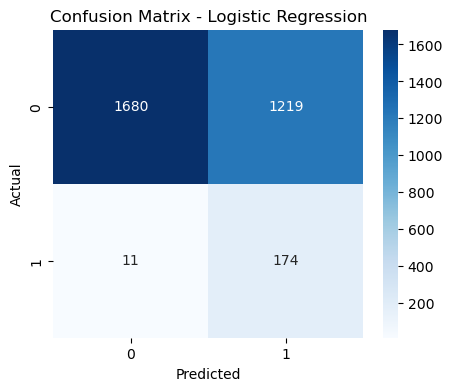

In [22]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/logistic_confusion_matrix.png", bbox_inches='tight')

plt.show()

In [23]:
#ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8122148364300831


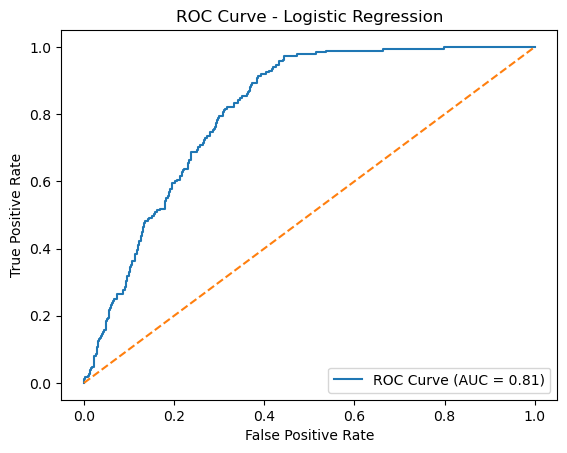

In [24]:
#ROC curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.savefig("../reports/figures/roc_curve_logistic.png", bbox_inches='tight')
plt.show()

In [25]:
#Save model
import joblib
#Create folder
os.makedirs("../models", exist_ok=True)

#Save model
joblib.dump(model, "../models/logistic_model.pkl")

['../models/logistic_model.pkl']